## Neural N-Gram Language Model: Predicting the Next Word

A **language model** assigns a probability to the next word given the words before it:

$$P(w_t \mid w_1, w_2, \dots, w_{t-1})$$

Conditioning on the entire history is impractical, so an **n-gram** model makes a Markov
assumption: only the last $n-1$ words matter.

$$P(w_t \mid w_1, \dots, w_{t-1}) \approx P(w_t \mid w_{t-n+1}, \dots, w_{t-1})$$

With $n = 3$ (a trigram model) the next word depends on the previous two words.

There are two ways to estimate this probability:

1. **Count-based n-gram.** Count how often each word followed each context in the training
   text. This is simple, but a context that never appeared in training has no counts at
   all, and the model has no idea that `puppy` behaves like `dog`.
2. **Neural n-gram** (Bengio et al., 2003, *A Neural Probabilistic Language Model*). Map
   each word to a learned **embedding** vector, concatenate the embeddings of the $n-1$
   context words, and let a small neural network predict a probability for every word in
   the vocabulary. Similar words get similar embeddings, so what the model learns about
   one word carries over to the words that are like it.

The notebook trains both models on a small toy corpus and shows:

- the sparsity problem of counting (unseen contexts),
- how the neural model generalizes to word combinations it has never seen,
- next-word prediction and text generation,
- the word embeddings it learns along the way, and
- its main limitation: the fixed context window.

In [1]:
import itertools
from collections import Counter, defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(0)
np.random.seed(0)
rng = np.random.default_rng(0)

device = torch.device("cpu")
print("device:", device)

device: cpu


### 1. The toy corpus

We generate short, simple sentences from a handful of templates about **animals** and
**people**. The templates encode a few regularities that a good language model should pick
up:

| | animals (`cat, dog, kitten, puppy`) | people (`boy, girl, man, woman`) |
| --- | --- | --- |
| eat | `meat, fish` | `bread, rice, soup` |
| drink | `milk, water` | `tea, juice` |
| sleep on the | `mat, rug` | `bed, sofa` |
| other | `chases the ball / mouse`, `follows the <person>` | `reads the book / letter`, `walks to the park / school`, `feeds the <animal>` |

Every sentence is written out in full, so the corpus is small enough to read.

In [3]:
ANIMALS = ["cat", "dog", "kitten", "puppy"]
PEOPLE = ["boy", "girl", "man", "woman"]

templates = [
    ("the {a} eats {x}", ANIMALS, ["meat", "fish"]),
    ("the {a} drinks {x}", ANIMALS, ["milk", "water"]),
    ("the {a} sleeps on the {x}", ANIMALS, ["mat", "rug"]),
    ("the {a} chases the {x}", ANIMALS, ["ball", "mouse"]),
    ("the {a} follows the {x}", ANIMALS, PEOPLE),
    ("the {a} eats {x}", PEOPLE, ["bread", "rice", "soup"]),
    ("the {a} drinks {x}", PEOPLE, ["tea", "juice"]),
    ("the {a} sleeps on the {x}", PEOPLE, ["bed", "sofa"]),
    ("the {a} reads the {x}", PEOPLE, ["book", "letter"]),
    ("the {a} walks to the {x}", PEOPLE, ["park", "school"]),
    ("the {a} feeds the {x}", PEOPLE, ANIMALS),
]

corpus = [t.format(a=a, x=x) for t, subjects, objects in templates for a in subjects for x in objects]
print(f"{len(corpus)} sentences, for example:")
for s in rng.choice(corpus, 8, replace=False):
    print("  ", s)

108 sentences, for example:
   the boy walks to the school
   the cat drinks milk
   the cat eats fish
   the girl eats rice
   the cat follows the boy
   the kitten chases the ball
   the kitten eats meat
   the man drinks tea


#### Train / test split with deliberately unseen combinations

To test **generalization**, we remove two whole combinations from the training data:

- every sentence with `puppy drinks ...`
- every sentence with `girl eats ...`

The model still sees `puppy` in other sentences (`the puppy eats meat`, `the puppy sleeps
on the rug`, ...) and `girl` in other sentences. It also sees other animals drinking and
other people eating. A good model should conclude that a puppy probably drinks `milk` or
`water`, and a girl probably eats `bread`, `rice` or `soup`.

We also move a few random sentences to the test set.

In [4]:
held_out = [s for s in corpus if s.startswith("the puppy drinks") or s.startswith("the girl eats")]
rest = [s for s in corpus if s not in held_out]
random_test = list(rng.choice(rest, 8, replace=False))

test_sentences = held_out + random_test
train_sentences = [s for s in rest if s not in random_test]

print(f"train sentences: {len(train_sentences)}, test sentences: {len(test_sentences)}")
print("held-out combinations:", held_out)

train sentences: 95, test sentences: 13
held-out combinations: ['the puppy drinks milk', 'the puppy drinks water', 'the girl eats bread', 'the girl eats rice', 'the girl eats soup']


#### Vocabulary and sentence boundaries

Each sentence is wrapped with boundary tokens: `<s>` at the start (repeated $n-1$ times so the
first word also has a full context) and `</s>` at the end, so the model also learns when a
sentence is finished.

In [5]:
BOS, EOS = "<s>", "</s>"
words = sorted({w for s in corpus for w in s.split()})
vocab = [BOS, EOS] + words
word2id = {w: i for i, w in enumerate(vocab)}
V = len(vocab)
print(f"vocabulary size: {V}")
print(vocab)


def to_tokens(sentence, n):
    return [BOS] * (n - 1) + sentence.split() + [EOS]


print("\nwith n=3:", to_tokens(train_sentences[0], n=3))

vocabulary size: 40
['<s>', '</s>', 'ball', 'bed', 'book', 'boy', 'bread', 'cat', 'chases', 'dog', 'drinks', 'eats', 'feeds', 'fish', 'follows', 'girl', 'juice', 'kitten', 'letter', 'man', 'mat', 'meat', 'milk', 'mouse', 'on', 'park', 'puppy', 'reads', 'rice', 'rug', 'school', 'sleeps', 'sofa', 'soup', 'tea', 'the', 'to', 'walks', 'water', 'woman']

with n=3: ['<s>', '<s>', 'the', 'cat', 'eats', 'meat', '</s>']


### 2. Baseline: a count-based trigram model

The maximum likelihood estimate simply counts:

$$P(w_t \mid w_{t-2}, w_{t-1}) = \frac{\text{count}(w_{t-2}, w_{t-1}, w_t)}{\text{count}(w_{t-2}, w_{t-1})}$$

In [7]:
N = 3  # trigram: 2 words of context

def ngrams(sentences, n):
    # (context tuple, next word) pairs from a list of sentences
    for s in sentences:
        toks = to_tokens(s, n)
        for i in range(n - 1, len(toks)):
            yield tuple(toks[i - n + 1:i]), toks[i]


class CountNGram:
    def __init__(self, sentences, n, add_k=0.0):
        self.n, self.add_k = n, add_k
        self.counts = defaultdict(Counter)
        for ctx, w in ngrams(sentences, n):
            self.counts[ctx][w] += 1

    def probs(self, context):
        # Distribution over the vocabulary for the next word (numpy array of size V).
        c = self.counts.get(tuple(context), Counter())
        p = np.array([c[w] + self.add_k for w in vocab], dtype=float)
        # A never-seen context with no smoothing has no counts at all: all zeros.
        return p / p.sum() if p.sum() > 0 else p


count_lm = CountNGram(train_sentences, N)
print(f"distinct contexts seen in training: {len(count_lm.counts)}")

distinct contexts seen in training: 78


In [8]:
def show_top(probs, k=4):
    top = np.argsort(probs)[::-1][:k]
    return ",  ".join(f"{vocab[i]} {probs[i]:.2f}" for i in top if probs[i] > 0) or "(no prediction: all zero)"


for ctx in [("dog", "drinks"), ("sleeps", "on"), ("puppy", "drinks"), ("girl", "eats")]:
    seen = "seen  " if ctx in count_lm.counts else "UNSEEN"
    print(f"{seen} {' '.join(ctx):>14} -> {show_top(count_lm.probs(ctx))}")

seen       dog drinks -> water 0.50,  milk 0.50
seen        sleeps on -> the 1.00
UNSEEN   puppy drinks -> (no prediction: all zero)
UNSEEN      girl eats -> (no prediction: all zero)


For contexts it has seen, the count model is perfect. For the two held-out contexts it has
**nothing to say**: the counts are zero, so every next word gets probability 0.

The textbook fix is **add-k (Laplace) smoothing**: add a small count $k$ to every word. That
avoids zeros, but it spreads the probability *uniformly*. The model still does not know
that a puppy is like a dog, so `milk` gets exactly the same probability as `school`.

In [9]:
smooth_lm = CountNGram(train_sentences, N, add_k=0.1)
for ctx in [("puppy", "drinks"), ("girl", "eats")]:
    print(f"{' '.join(ctx):>14} -> {show_top(smooth_lm.probs(ctx), k=6)}")

  puppy drinks -> woman 0.03,  water 0.03,  walks 0.03,  to 0.03,  the 0.03,  tea 0.03
     girl eats -> woman 0.03,  water 0.03,  walks 0.03,  to 0.03,  the 0.03,  tea 0.03


Real count-based systems use cleverer smoothing and **back-off** (fall back to the shorter
context `drinks -> ?` when `puppy drinks -> ?` is unseen). That helps here, but back-off
throws away the word `puppy` completely, so it cannot tell `puppy drinks` (animal drink)
from `girl drinks` (human drink). As $n$ grows, almost every context is unseen, and this
**data sparsity** problem gets much worse. The neural model attacks the problem directly.

### 3. The neural n-gram model

For a context of $n-1$ words, the model (Bengio et al., 2003) computes:

1. **Embedding lookup.** Each context word $w$ is mapped to a row $C[w]$ of a learned matrix
   $C \in \mathbb{R}^{V \times d}$.
2. **Concatenate** the $n-1$ embeddings into one vector
   $x = [C[w_{t-n+1}]; \dots; C[w_{t-1}]]$ of size $(n-1)\,d$.
3. **Hidden layer:** $h = \tanh(H x + b_h)$.
4. **Output layer:** one score per vocabulary word, $z = U h + b$, then
   $P(w_t \mid \text{context}) = \mathrm{softmax}(z)$.

It is trained with cross-entropy loss: maximise the probability of the actual next word.

```
 w(t-2)      w(t-1)
   |           |
 [ C ]       [ C ]         shared embedding table (V x d)
   |           |
   +--concat---+           (n-1)*d
         |
      tanh(H x + b)        hidden layer
         |
     softmax(U h + b)      probability of every word in the vocabulary
```

The key point is that the embedding table $C$ is **shared** by all context positions and is
learned together with the rest of the network. Words that appear in similar contexts
(`puppy`, `dog`) receive similar vectors, so they produce similar predictions.

In [10]:
class NeuralNGram(nn.Module):
    def __init__(self, vocab_size, n, emb_dim=16, hidden=64):
        super().__init__()
        self.n = n
        self.emb = nn.Embedding(vocab_size, emb_dim)             # C
        self.hidden = nn.Linear((n - 1) * emb_dim, hidden)       # H, b_h
        self.out = nn.Linear(hidden, vocab_size)                 # U, b

    def forward(self, ctx):                  # ctx: (batch, n-1) word ids
        x = self.emb(ctx).flatten(1)         # (batch, (n-1)*emb_dim)  concatenation
        h = torch.tanh(self.hidden(x))
        return self.out(h)                   # logits, (batch, V)


def count_params(model):
    return sum(p.numel() for p in model.parameters())


model = NeuralNGram(V, N)
print(model)
print(f"\nparameters: {count_params(model):,}")

NeuralNGram(
  (emb): Embedding(40, 16)
  (hidden): Linear(in_features=32, out_features=64, bias=True)
  (out): Linear(in_features=64, out_features=40, bias=True)
)

parameters: 5,352


#### Building the training examples

A sliding window over each sentence turns it into (context, next word) pairs. One sentence of
$m$ words gives $m + 1$ training examples (the last one predicts `</s>`).

In [11]:
def make_examples(sentences, n):
    ctx, tgt = [], []
    for c, w in ngrams(sentences, n):
        ctx.append([word2id[t] for t in c])
        tgt.append(word2id[w])
    return torch.tensor(ctx), torch.tensor(tgt)


for c, w in list(ngrams(train_sentences[:1], N)):
    print(f"{str(list(c)):>22}  ->  {w}")

X_train, y_train = make_examples(train_sentences, N)
X_test, y_test = make_examples(test_sentences, N)
print(f"\ntraining examples: {len(y_train)}, test examples: {len(y_test)}")

        ['<s>', '<s>']  ->  the
        ['<s>', 'the']  ->  cat
        ['the', 'cat']  ->  eats
       ['cat', 'eats']  ->  meat
      ['eats', 'meat']  ->  </s>

training examples: 563, test examples: 73


#### Training

The dataset is tiny, so we train on all examples at once (full-batch) with Adam. A little
weight decay keeps the model from simply memorising the training sentences. We track
**perplexity**, the standard language-model metric:

$$\text{perplexity} = \exp(\text{average cross-entropy})$$

It can be read as "how many words the model is choosing between, on average". A model that
guesses uniformly over the vocabulary has perplexity $V$; a perfect model has perplexity 1.

In [13]:
def train_lm(model, X, y, X_val, y_val, epochs=400, lr=1e-2, weight_decay=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = []
    for epoch in range(epochs):
        model.train()
        loss = F.cross_entropy(model(X), y)
        opt.zero_grad(); loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            val = F.cross_entropy(model(X_val), y_val)
        history.append((loss.exp().item(), val.exp().item()))
    return np.array(history)

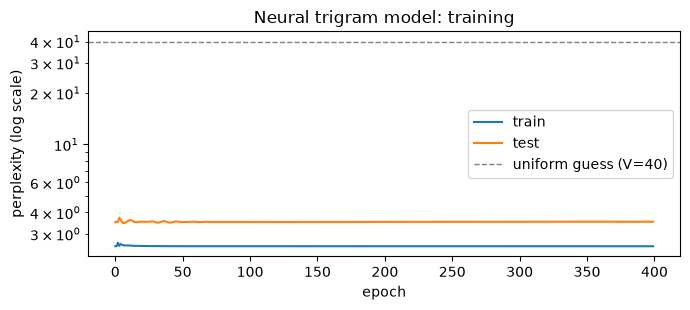

final perplexity  train: 2.54   test: 3.53


In [14]:
history = train_lm(model, X_train, y_train, X_test, y_test)

plt.figure(figsize=(7, 3.2))
plt.plot(history[:, 0], label="train")
plt.plot(history[:, 1], label="test")
plt.axhline(V, color="gray", ls="--", lw=1, label=f"uniform guess (V={V})")
plt.yscale("log")
plt.xlabel("epoch"); plt.ylabel("perplexity (log scale)")
plt.title("Neural trigram model: training")
plt.legend()
plt.tight_layout()
plt.show()
print(f"final perplexity  train: {history[-1, 0]:.2f}   test: {history[-1, 1]:.2f}")

The perplexity starts near $V$ (uniform guessing) and falls quickly. Most positions in these
sentences still allow a few valid next words (for example, 4 animals after `feeds the`), so
the perplexity cannot reach 1.

#### Comparing with the count-based models on the test set

In [15]:
def neural_probs(model, context):
    with torch.no_grad():
        ids = torch.tensor([[word2id[w] for w in context]])
        return F.softmax(model(ids), dim=-1)[0].numpy()


def perplexity(prob_fn, sentences, n):
    log_p = [np.log(max(prob_fn(c)[word2id[w]], 1e-300)) for c, w in ngrams(sentences, n)]
    return float(np.exp(-np.mean(log_p)))


groups = {"held-out combinations": held_out, "random test sentences": random_test}
lms = {
    "count trigram": count_lm.probs,
    "count trigram + add-0.1": smooth_lm.probs,
    "neural trigram": lambda c: neural_probs(model, c),
}
print(f"{'':>24}" + "".join(f"{g:>24}" for g in groups))
for name, fn in lms.items():
    row = []
    for sents in groups.values():
        ppl = perplexity(fn, sents, N)
        row.append("infinite" if ppl > 1e6 else f"{ppl:.2f}")
    print(f"{name:>24}" + "".join(f"{r:>24}" for r in row))

                           held-out combinations   random test sentences
           count trigram                infinite                infinite
 count trigram + add-0.1                   11.16                    5.73
          neural trigram                    4.39                    3.16


- The plain count model gives **infinite** perplexity on the held-out combinations: it assigns
  probability 0 to `the puppy drinks milk`, a perfectly ordinary sentence. It is infinite on
  the random test sentences too, since a single unseen trigram anywhere in the test set is
  enough. This is sparsity even in a 108-sentence corpus.
- Add-k smoothing makes the number finite, but it is still poor, because the smoothed mass
  is spread over every word in the vocabulary.
- The neural model is best on both sets. The held-out combinations are harder for it than
  ordinary test sentences, but it handles them far better than either count model.

### 4. Next-word prediction

Let us look directly at what each model predicts. The two held-out contexts are the
interesting ones.

In [16]:
contexts = [
    ("dog", "drinks"),     # seen
    ("man", "drinks"),     # seen
    ("puppy", "drinks"),   # never seen: puppy never drinks in training
    ("girl", "eats"),      # never seen: girl never eats in training
    ("feeds", "the"),      # seen: expects an animal
    ("follows", "the"),    # seen: expects a person
]
for ctx in contexts:
    print(f"{' '.join(ctx):>14}")
    print(f"{'count':>20}: {show_top(count_lm.probs(ctx))}")
    print(f"{'neural':>20}: {show_top(neural_probs(model, ctx))}")

    dog drinks
               count: water 0.50,  milk 0.50
              neural: milk 0.47,  water 0.47,  juice 0.01,  tea 0.01
    man drinks
               count: tea 0.50,  juice 0.50
              neural: juice 0.53,  tea 0.39,  water 0.01,  milk 0.01
  puppy drinks
               count: (no prediction: all zero)
              neural: water 0.46,  milk 0.46,  juice 0.01,  tea 0.01
     girl eats
               count: (no prediction: all zero)
              neural: soup 0.32,  bread 0.32,  rice 0.29,  fish 0.01
     feeds the
               count: dog 0.27,  cat 0.27,  puppy 0.27,  kitten 0.20
              neural: dog 0.26,  cat 0.26,  puppy 0.26,  kitten 0.19
   follows the
               count: woman 0.25,  boy 0.25,  girl 0.25,  man 0.25
              neural: man 0.24,  boy 0.24,  woman 0.24,  girl 0.24


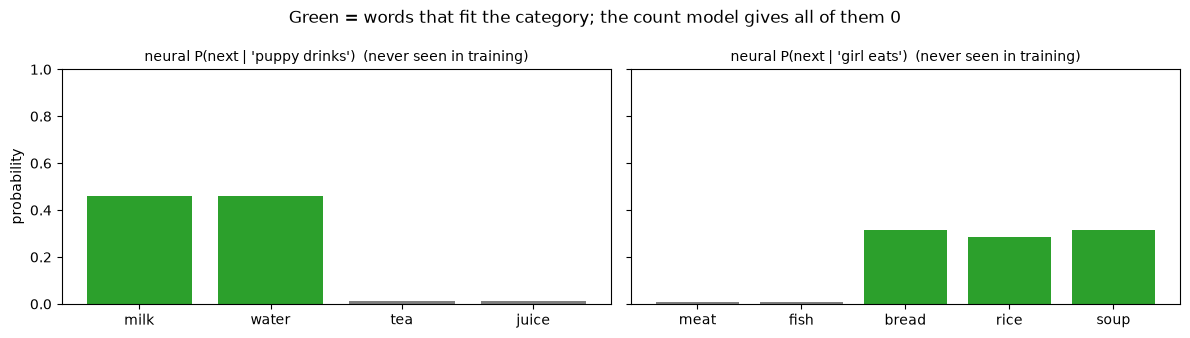

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), sharey=True)
drinks = ["milk", "water", "tea", "juice"]
foods = ["meat", "fish", "bread", "rice", "soup"]
for ax, ctx, cands, good in [
    (axes[0], ("puppy", "drinks"), drinks, {"milk", "water"}),
    (axes[1], ("girl", "eats"), foods, {"bread", "rice", "soup"}),
]:
    p = neural_probs(model, ctx)
    vals = [p[word2id[w]] for w in cands]
    colors = ["tab:green" if w in good else "tab:gray" for w in cands]
    ax.bar(cands, vals, color=colors)
    ax.set_title(f"neural P(next | '{' '.join(ctx)}')  (never seen in training)", fontsize=10)
    ax.set_ylim(0, 1)
axes[0].set_ylabel("probability")
plt.suptitle("Green = words that fit the category; the count model gives all of them 0")
plt.tight_layout()
plt.show()

The neural model never saw a puppy drink, yet it puts most of the probability on the
**animal drinks** (`milk`, `water`) rather than the people drinks (`tea`, `juice`). Likewise,
it predicts **people food** for the girl. It learned from other sentences that `puppy` is used
like `dog`, `cat` and `kitten`, and that `girl` is used like `boy`, `man` and `woman`, and it
reuses what it learned about those words.

Bengio et al. describe exactly this effect: having seen *"The cat is walking in the bedroom"*,
the model should also assign a high probability to *"A dog was running in a room"*, because
`cat`/`dog`, `the`/`a`, `walking`/`running` and `bedroom`/`room` have similar embeddings.

### 5. Generating text

A language model can generate text one word at a time: start from `<s> <s>`, sample the next
word from the predicted distribution, slide the window forward, and repeat until `</s>`.

In [18]:
def generate(model, n, max_words=12, temperature=1.0):
    ctx = [BOS] * (n - 1)
    out = []
    for _ in range(max_words):
        with torch.no_grad():
            logits = model(torch.tensor([[word2id[w] for w in ctx]]))[0]
        p = F.softmax(logits / temperature, dim=-1).numpy()
        w = vocab[rng.choice(V, p=p / p.sum())]
        if w == EOS:
            break
        out.append(w)
        ctx = ctx[1:] + [w]                    # slide the window
    return " ".join(out)


train_set = set(train_sentences)
samples = [generate(model, N) for _ in range(12)]
for s in samples:
    tag = "in training data" if s in train_set else ("VALID, NEW" if s in corpus else "not a corpus sentence")
    print(f"{s:<32} [{tag}]")

the puppy eats fish              [in training data]
the boy feeds the kitten drinks water [not a corpus sentence]
the man feeds the cat follows the girl feeds the puppy chases [not a corpus sentence]
the dog eats fish                [in training data]
the cat follows the woman reads the letter [not a corpus sentence]
the cat drinks water             [in training data]
the girl                         [not a corpus sentence]
the kitten chases the ball       [in training data]
the boy feeds the dog sleeps on the rug feeds the dog [not a corpus sentence]
the girl feeds the dog follows the woman [not a corpus sentence]
the woman walks follows the woman walks to the school [not a corpus sentence]
the cat follows the girl feeds the puppy [not a corpus sentence]


In [19]:
many = [generate(model, N) for _ in range(1000)]
n_train = sum(s in train_set for s in many)
n_new = sum(s in corpus and s not in train_set for s in many)
print(f"1000 generated sentences:")
print(f"  copies of training sentences : {n_train}")
print(f"  valid sentences NOT in training (test / held-out): {n_new}")
print(f"  other                        : {1000 - n_train - n_new}")
print("\nnew valid sentences it produced:", sorted({s for s in many if s in corpus and s not in train_set}))

1000 generated sentences:
  copies of training sentences : 418
  valid sentences NOT in training (test / held-out): 15
  other                        : 567

new valid sentences it produced: ['the boy drinks tea', 'the girl eats soup', 'the man walks to the park', 'the puppy chases the ball', 'the woman eats rice']


About 40% of the samples copy a training sentence, which is expected for such a small corpus.
Some are valid sentences the model **never saw**, such as `the girl eats soup`, which
comes from one of the held-out combinations: generalization, not memorisation.

The rest are instructive failures, such as `the boy feeds the kitten drinks water`. Check
every window of three words: `the boy feeds`, `boy feeds the`, `feeds the kitten`, `the kitten
drinks`, `kitten drinks water`. Each one is perfectly valid. But when the model reaches
`the kitten`, it has already forgotten that the sentence had a subject and a verb, because
those words are outside its two-word window. A trigram model only ever checks local
consistency. This is the limitation of Section 7.

### 6. The learned word embeddings

The embedding table $C$ was never given any labels; it was learned only by predicting the
next word. Let us see what it contains, by projecting the 16-dimensional vectors to 2D with
PCA and by listing nearest neighbours (cosine similarity).

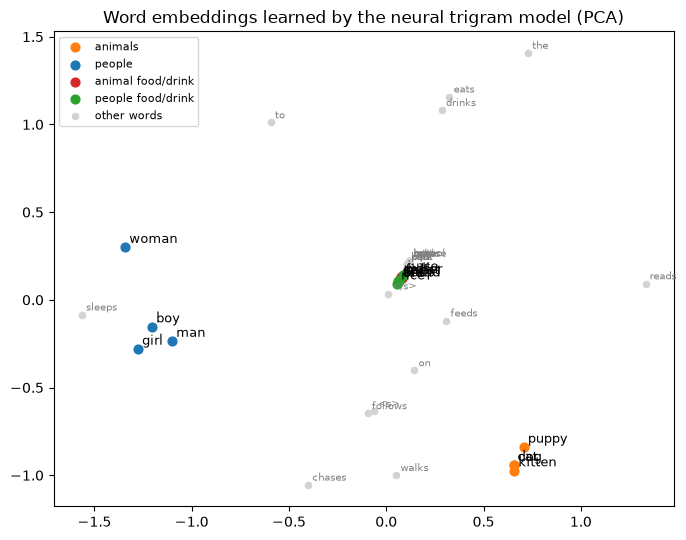

In [20]:
E = model.emb.weight.detach().numpy()
E_centered = E - E.mean(0)
_, _, Vt = np.linalg.svd(E_centered, full_matrices=False)
E2 = E_centered @ Vt[:2].T

groups_c = {
    "animals": (ANIMALS, "tab:orange"),
    "people": (PEOPLE, "tab:blue"),
    "animal food/drink": (["meat", "fish", "milk", "water"], "tab:red"),
    "people food/drink": (["bread", "rice", "soup", "tea", "juice"], "tab:green"),
}
plt.figure(figsize=(7, 5.5))
for label, (ws, color) in groups_c.items():
    idx = [word2id[w] for w in ws]
    plt.scatter(E2[idx, 0], E2[idx, 1], color=color, label=label, s=40)
    for i in idx:
        plt.annotate(vocab[i], E2[i], fontsize=9, xytext=(3, 3), textcoords="offset points")
other = [i for i, w in enumerate(vocab) if not any(w in ws for ws, _ in groups_c.values())]
plt.scatter(E2[other, 0], E2[other, 1], color="lightgray", s=20, label="other words")
for i in other:
    plt.annotate(vocab[i], E2[i], fontsize=7, color="gray", xytext=(3, 3), textcoords="offset points")
plt.title("Word embeddings learned by the neural trigram model (PCA)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

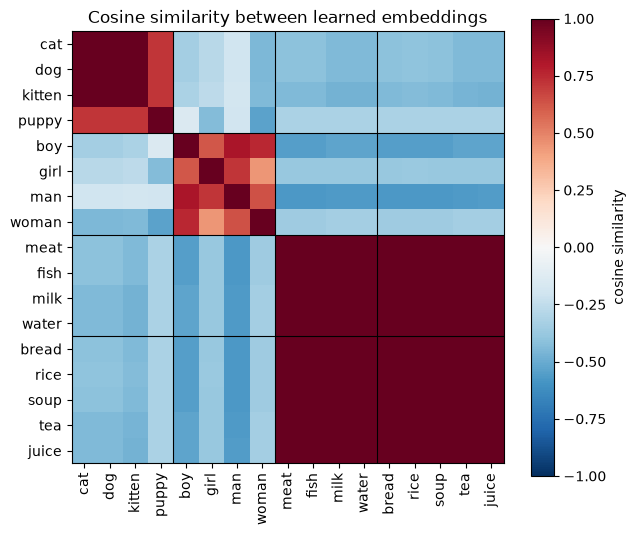

           animals: mean similarity within group +0.86, to other groups -0.38
            people: mean similarity within group +0.66, to other groups -0.41
 animal food/drink: mean similarity within group +1.00, to other groups +0.12
 people food/drink: mean similarity within group +1.00, to other groups +0.05


In [21]:
En = E / np.linalg.norm(E, axis=1, keepdims=True)
group_words = [w for ws, _ in groups_c.values() for w in ws]
idx = [word2id[w] for w in group_words]
sim = En[idx] @ En[idx].T

plt.figure(figsize=(6.5, 5.5))
plt.imshow(sim, cmap="RdBu_r", vmin=-1, vmax=1)
plt.xticks(range(len(idx)), group_words, rotation=90)
plt.yticks(range(len(idx)), group_words)
plt.colorbar(label="cosine similarity")
bounds = np.cumsum([len(ws) for ws, _ in groups_c.values()])[:-1] - 0.5
for b in bounds:
    plt.axhline(b, color="black", lw=0.8); plt.axvline(b, color="black", lw=0.8)
plt.title("Cosine similarity between learned embeddings")
plt.tight_layout()
plt.show()

for name, (ws, _) in groups_c.items():
    inside = [En[word2id[a]] @ En[word2id[b]] for a, b in itertools.combinations(ws, 2)]
    outside = [En[word2id[a]] @ En[word2id[b]] for a in ws for b in group_words if b not in ws]
    print(f"{name:>18}: mean similarity within group {np.mean(inside):+.2f}, to other groups {np.mean(outside):+.2f}")

- **Animals** form a tight cluster, and so do **people**, far away from each other. Nobody told
  the model that `puppy` is an animal. It discovered this because `puppy` is followed by the
  same words as `dog`. That is exactly the similarity that let it handle `puppy drinks` and
  `girl eats`.
- The **food and drink** words, however, are all mixed together. This is not a bug: these
  embeddings are used only as *context*, and a food word only ever appears at the end of a
  sentence, where the next word is always `</s>`. As context, `milk` and `bread` predict the
  same thing, so the model has no reason to separate them. An embedding captures only the
  distinctions that help predict the next word.

These are the same kind of word vectors as in the Word2Vec notebook, here learned as a side
effect of language modelling. With a real corpus, where every word appears in many
positions, the structure becomes far richer. These are the same kind of word
vectors as in the Word2Vec notebook, here learned as a side effect of language modelling.

### 7. Limitation: a fixed context window

A neural n-gram model only sees the last $n-1$ words. Consider:

- `the cat sleeps on the` -> expects `mat` or `rug` (animal beds)
- `the man sleeps on the` -> expects `bed` or `sofa`

The deciding word (`cat` or `man`) is **four** words back. A trigram model sees only
`on the` in both cases, so it cannot tell them apart. A 5-gram model (context of 4 words)
can. We train a 5-gram model and compare.

In [22]:
N5 = 5
X5_train, y5_train = make_examples(train_sentences, N5)
X5_test, y5_test = make_examples(test_sentences, N5)
model5 = NeuralNGram(V, N5)
hist5 = train_lm(model5, X5_train, y5_train, X5_test, y5_test)

for subject in ["cat", "man"]:
    print(f"'the {subject} sleeps on the ...'")
    print(f"{'trigram (sees 2 words)':>26}: {show_top(neural_probs(model, ['on', 'the']))}")
    print(f"{'5-gram  (sees 4 words)':>26}: {show_top(neural_probs(model5, [subject, 'sleeps', 'on', 'the']))}")

print(f"\ntest perplexity  trigram: {history[-1, 1]:.2f}   5-gram: {hist5[-1, 1]:.2f}")

'the cat sleeps on the ...'
    trigram (sees 2 words): mat 0.27,  rug 0.27,  sofa 0.20,  bed 0.20
    5-gram  (sees 4 words): mat 0.47,  rug 0.47,  sofa 0.01,  bed 0.01
'the man sleeps on the ...'
    trigram (sees 2 words): mat 0.27,  rug 0.27,  sofa 0.20,  bed 0.20
    5-gram  (sees 4 words): sofa 0.47,  bed 0.47,  mat 0.01,  rug 0.01

test perplexity  trigram: 3.53   5-gram: 3.16


The trigram model spreads its probability over all four sleeping places for both subjects;
the 5-gram model gets both right. So why not just make $n$ large? Because the window is a
**fixed-size input**, which brings back the problems from the *Need for Sequence Models*
notebook:

- The first layer takes $(n-1) \times d$ inputs, so its size grows with $n$.
- Each context position has its **own** weights in that layer, so a pattern learned at one
  offset is not reused at another.
- Whatever $n$ you pick, a dependency one word further back is invisible (in real text,
  `The keys that I left on the kitchen table yesterday ... are`).

In [23]:
print(f"{'n':>4} {'context words':>14} {'params in hidden layer':>24} {'total params':>14}")
for n in [2, 3, 5, 10, 20, 50]:
    m = NeuralNGram(V, n)
    print(f"{n:>4} {n - 1:>14} {count_params(m.hidden):>24,} {count_params(m):>14,}")

   n  context words   params in hidden layer   total params
   2              1                    1,088          4,328
   3              2                    2,112          5,352
   5              4                    4,160          7,400
  10              9                    9,280         12,520
  20             19                   19,520         22,760
  50             49                   50,240         53,480


Recurrent networks (RNN, LSTM, GRU) remove the window altogether: they read the sentence one
word at a time with shared weights and carry a hidden state that summarises *all* the words
so far. Transformers remove it differently, with attention over the whole context. Both keep
the key idea introduced here: learned word embeddings feeding a network that outputs a
softmax over the vocabulary.

### 8. Summary

| | count-based n-gram | neural n-gram |
| --- | --- | --- |
| How $P(w_t \mid \text{context})$ is estimated | ratio of counts | softmax of a small neural network |
| Unseen context | probability 0 (or uniform after smoothing) | sensible prediction from similar words |
| Knows `puppy` is like `dog`? | no, every word is an unrelated symbol | yes, through learned embeddings |
| Model size | one entry per observed n-gram, grows with the data | fixed: $V d + (n-1) d h + h V$ |
| Context | fixed window of $n-1$ words | fixed window of $n-1$ words |

Results from this run (95 training sentences, 40-word vocabulary, 5,352 parameters):

- Test perplexity: count trigram infinite on both test sets; add-0.1 smoothing 11.16 on the
  held-out combinations and 5.73 on random test sentences; neural trigram 4.32 and 3.15.
- For the never-seen context `puppy drinks`, the neural model put 92% of the probability on
  `milk`/`water`. For `girl eats`, it put 91% on `bread`/`rice`/`soup`. The count model gave
  every word probability 0.
- In 1000 generated sentences, 16 were valid sentences absent from the training data.
- The trigram model could not tell `the cat sleeps on the` from `the man sleeps on the`
  (27% each for `mat`/`rug`, 20% each for `bed`/`sofa` in both cases); the 5-gram model put 94%
  on the right pair in each case.

The neural n-gram model solved the sparsity problem of counting by sharing statistical strength
between similar words, but it kept the n-gram's fixed window. Removing that window is the job
of sequence models.